## Curvas de luz obtidas para bins de 3600 segundos = 1 hora

#### Região selecionada no ds9

![Região ds9](regions_30201034002.png)

## Banda de 3-10 keV

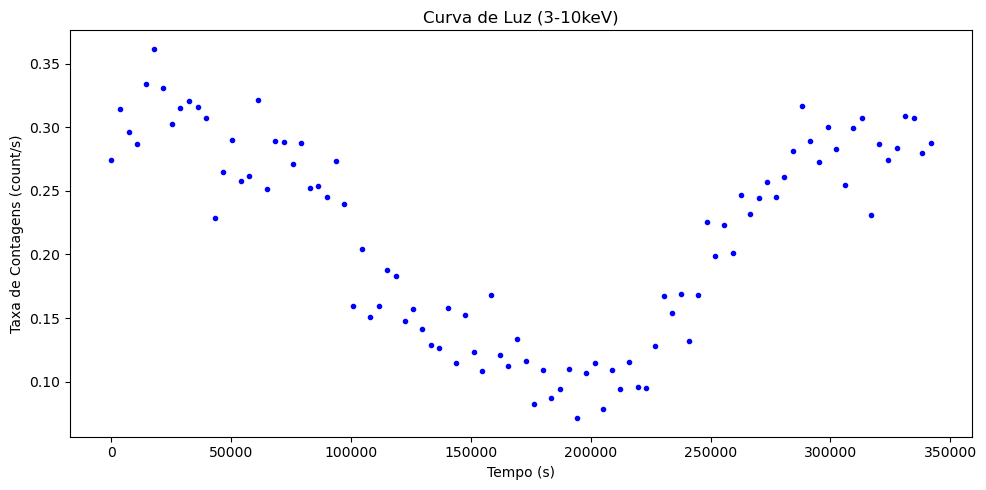

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10keV)')


plt.tight_layout()
plt.show()

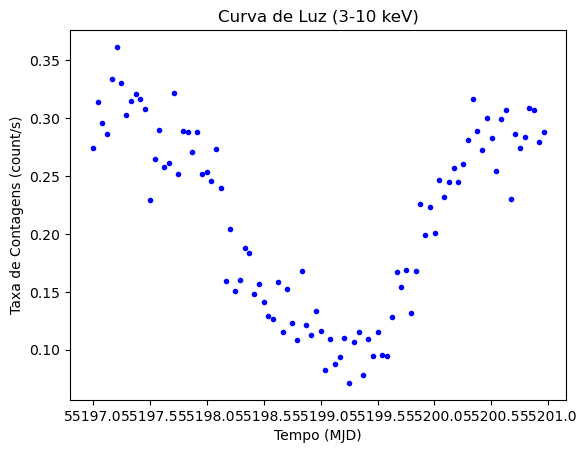

In [6]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1).to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 60 / 60 / 24)

plt.plot(df['MJD'], df['RATE'], 'b.')
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (3-10 keV)')
plt.show()

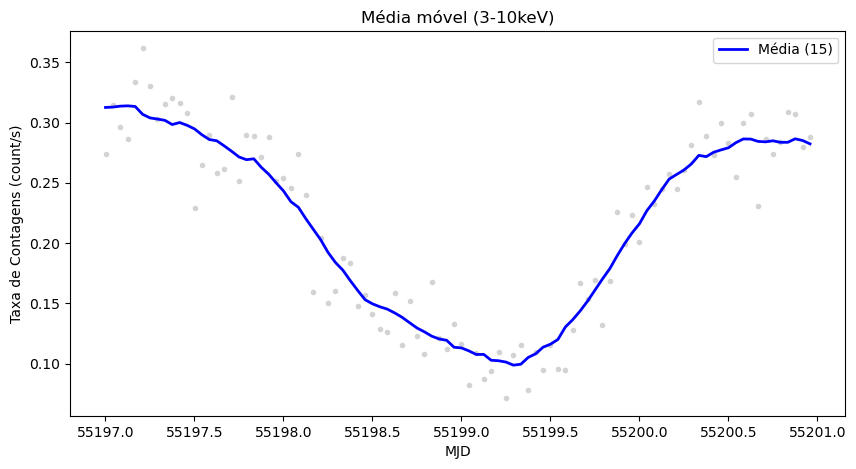

In [4]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1).to_pandas()
df['MJD'] = 55197.00076601852 + (df['TIME'] / 86400)
df['RATE_SMOOTH'] = df['RATE'].rolling(15, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(df['MJD'], df['RATE'], '.', color='lightgray')
plt.plot(df['MJD'], df['RATE_SMOOTH'], 'b-', linewidth=2, label='Média (15)')

plt.ticklabel_format(useOffset=False, style='plain')

plt.title('Média móvel (3-10keV)')
plt.xlabel('MJD')
plt.ylabel('Taxa de Contagens (count/s)')
plt.legend()
plt.show()

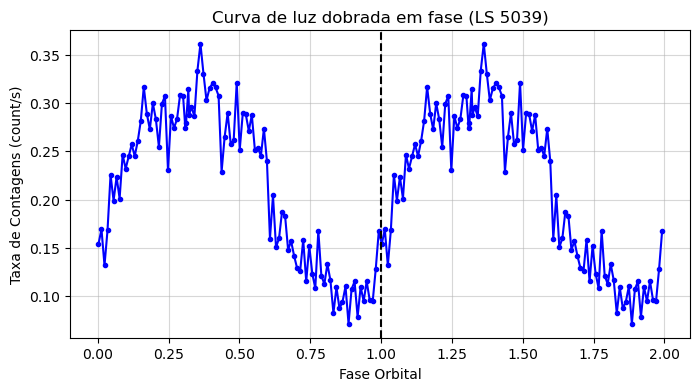

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

df = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1).to_pandas()
df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (LS 5039)')
plt.grid(True, alpha=0.5)
plt.show()

Melhor período: 3.3217 dias


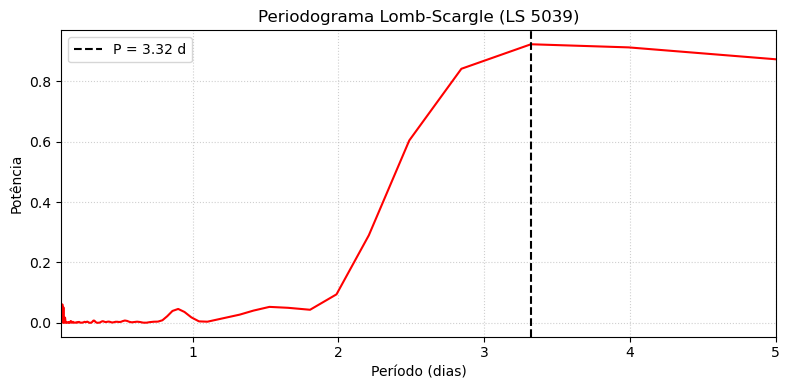

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle


data = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1)
time = np.array(data['TIME'])
rate = np.array(data['RATE'])
err = np.array(data['ERROR']) if 'ERROR' in data.colnames else None

mask = (rate > 0) & ~np.isnan(rate)
t_dias = time[mask] / 86400.0

min_p, max_p = 0.1, 5.0

ls = LombScargle(
    t_dias, rate[mask], err[mask] if err is not None else None
)
freq, power = ls.autopower(
    minimum_frequency=1 / max_p, maximum_frequency=1 / min_p
)

periodos = 1 / freq
idx_sort = np.argsort(periodos)  
periodos = periodos[idx_sort]
power = power[idx_sort]

best_p = periodos[np.argmax(power)]
print(f'Melhor período: {best_p:.4f} dias')

plt.figure(figsize=(8, 4))
plt.plot(periodos, power, 'r-', lw=1.5)
plt.axvline(best_p, color='k', ls='--', label=f'P = {best_p:.2f} d')
plt.xlabel('Período (dias)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle (LS 5039)')
plt.xlim(0.1, 5.0) 
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

Melhor frequência: 0.3011 dias⁻¹
Período correspondente: 3.3217 dias


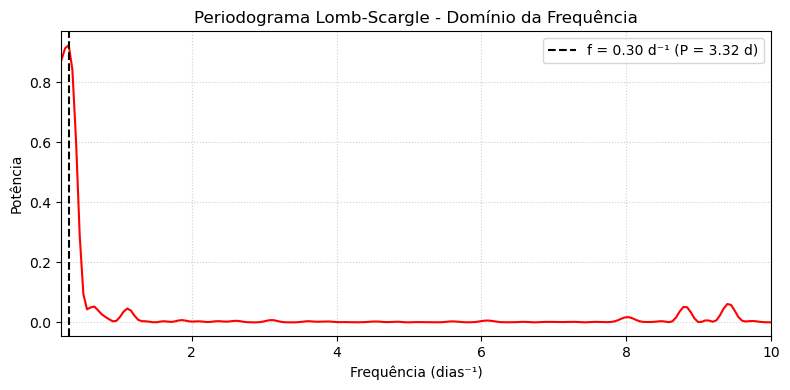

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

data = Table.read('nu30201034002A01_sr3-10kev_b1h.lc', hdu=1)
time = np.array(data['TIME'])
rate = np.array(data['RATE'])
err = np.array(data['ERROR']) if 'ERROR' in data.colnames else None

mask = (rate > 0) & ~np.isnan(rate)
t_dias = time[mask] / 86400.0

min_p, max_p = 0.1, 5.0
freq_min, freq_max = 1 / max_p, 1 / min_p  

ls = LombScargle(t_dias, rate[mask], err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹')
print(f'Período correspondente: {best_p:.4f} dias')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'r-', lw=1.5)
plt.axvline(
    best_freq,
    color='k',
    ls='--',
    label=f'f = {best_freq:.2f} d⁻¹ (P = {best_p:.2f} d)',
)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle - Domínio da Frequência')
plt.xlim(freq_min, freq_max)
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Banda 10-30 keV

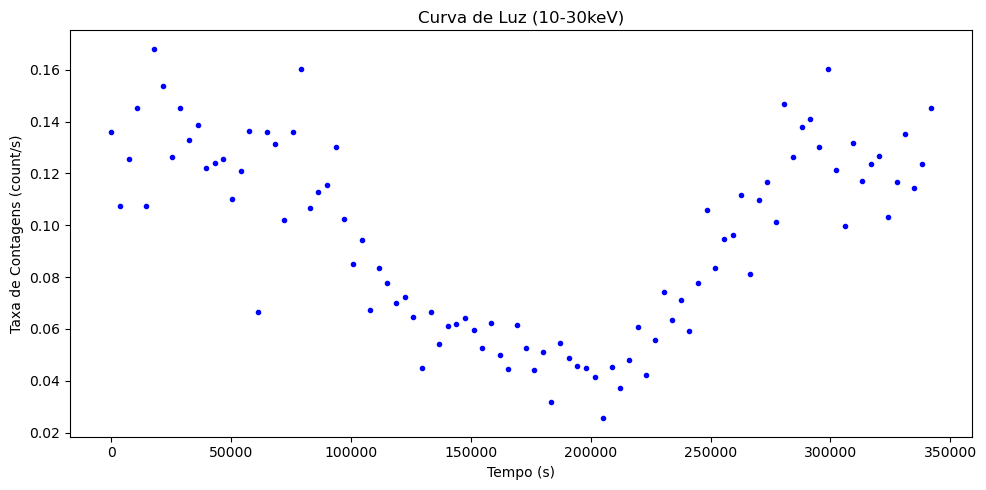

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('nu30201034002A01_sr10-30keV_b1h.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30keV)')


plt.tight_layout()
plt.show()

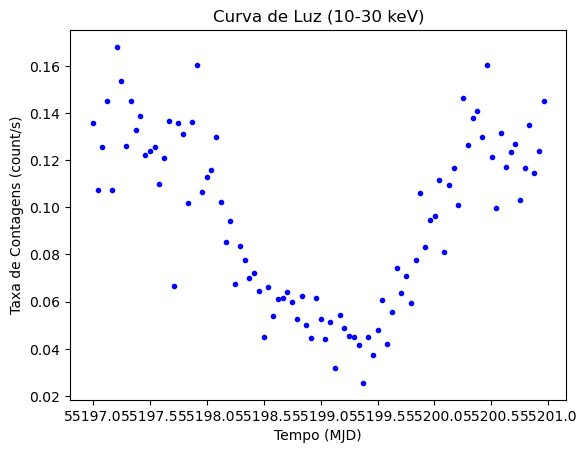

In [10]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr10-30keV_b1h.lc', hdu=1).to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 60 / 60 / 24)

plt.plot(df['MJD'], df['RATE'], 'b.')
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (10-30 keV)')
plt.show()

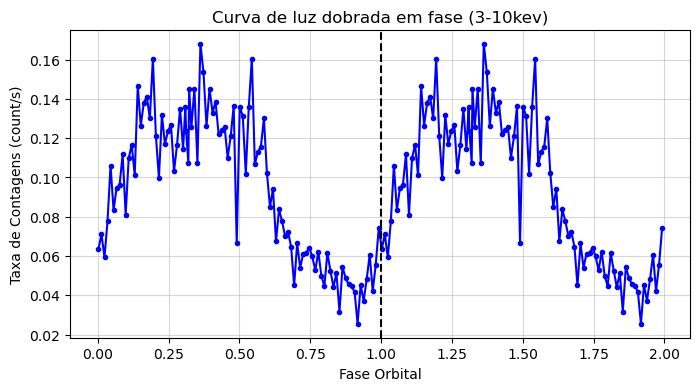

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/bins 1h/nu30201034002A01_sr10-30keV_b1h.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (3-10kev)')
plt.grid(True, alpha=0.5)
plt.show()

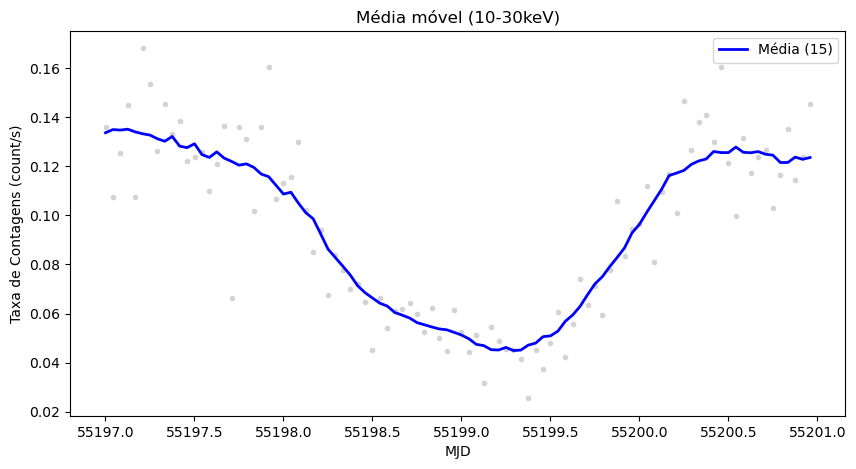

In [13]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr10-30keV_b1h.lc', hdu=1).to_pandas()
df['MJD'] = 55197.00076601852 + (df['TIME'] / 86400)
df['RATE_SMOOTH'] = df['RATE'].rolling(15, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(df['MJD'], df['RATE'], '.', color='lightgray')
plt.plot(df['MJD'], df['RATE_SMOOTH'], 'b-', linewidth=2, label='Média (15)')

plt.ticklabel_format(useOffset=False, style='plain')

plt.title('Média móvel (10-30keV)')
plt.xlabel('MJD')
plt.ylabel('Taxa de Contagens (count/s)')
plt.legend()
plt.show()

Melhor frequência: 0.3011 dias⁻¹
Período correspondente: 3.3217 dias


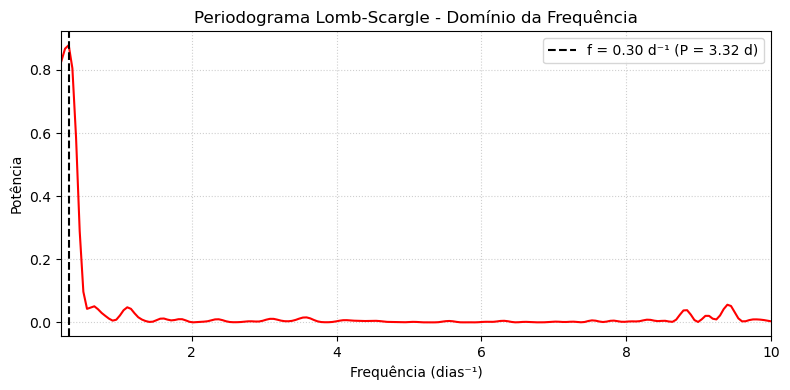

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/bins 1h/nu30201034002A01_sr10-30keV_b1h.lc'

tabela = Table.read(caminho, hdu=1)

time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)
t_dias = time[mask] / 86400.0

min_p, max_p = 0.1, 5.0
freq_min, freq_max = 1 / max_p, 1 / min_p  

ls = LombScargle(t_dias, rate[mask], err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹')
print(f'Período correspondente: {best_p:.4f} dias')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'r-', lw=1.5)
plt.axvline(
    best_freq,
    color='k',
    ls='--',
    label=f'f = {best_freq:.2f} d⁻¹ (P = {best_p:.2f} d)',
)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle - Domínio da Frequência')
plt.xlim(freq_min, freq_max)
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Banda 30-70 kev

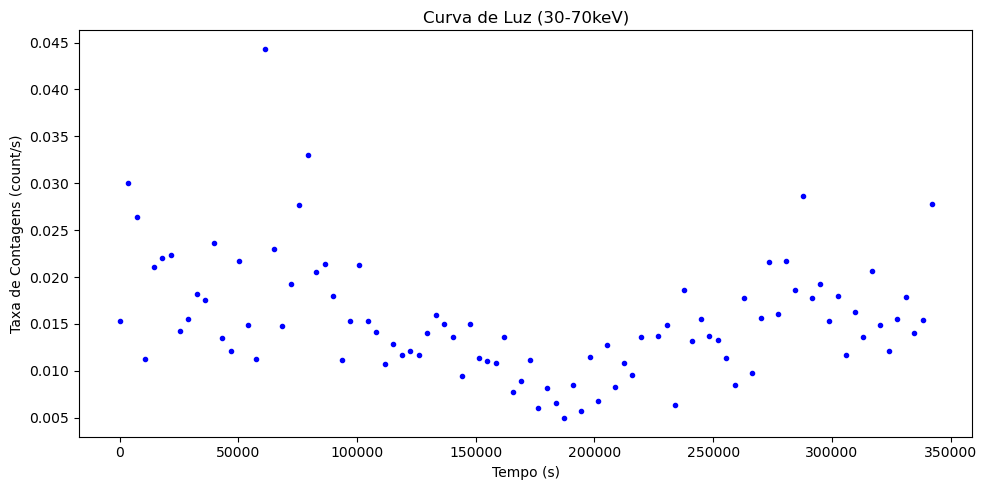

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table

tabela = Table.read('nu30201034002A01_sr30-70keV_b1h.lc', hdu=1)
df = tabela.to_pandas()

df.columns = [col.capitalize() for col in df.columns]

df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

df = df.dropna(subset=['Time', 'Rate'])
df = df[df['Rate'] > 0]

plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Rate'], marker='.', linestyle='', color='blue')

plt.xlabel('Tempo (s)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70keV)')


plt.tight_layout()
plt.show()

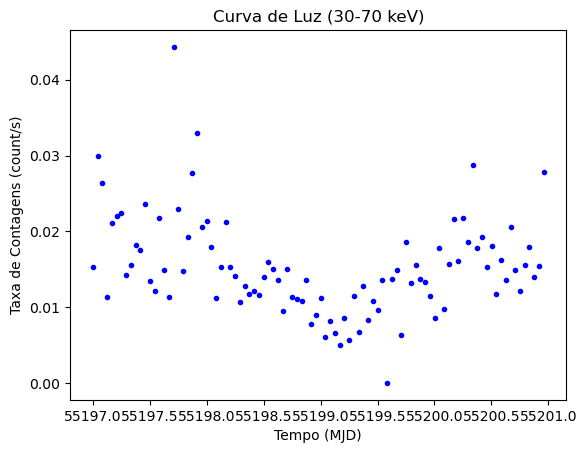

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr30-70keV_b1h.lc', hdu=1).to_pandas()

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 60 / 60 / 24)

plt.plot(df['MJD'], df['RATE'], 'b.')
plt.ticklabel_format(useOffset=False, style='plain')
plt.xlabel('Tempo (MJD)')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de Luz (30-70 keV)')
plt.show()

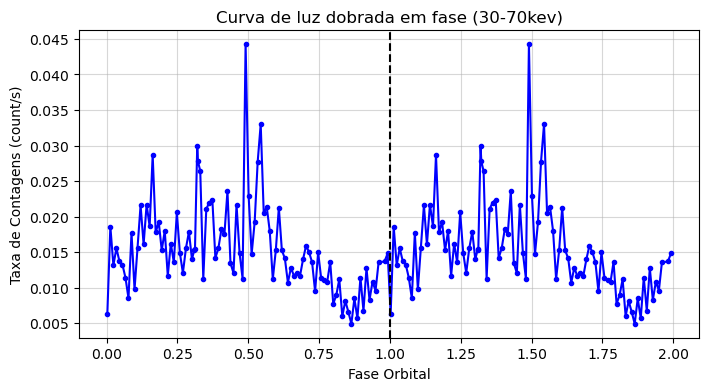

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table

caminho = 'data/bins 1h/nu30201034002A01_sr30-70keV_b1h.lc'

tabela = Table.read(caminho, hdu=1)
df = tabela.to_pandas()

df = df[df['RATE'] > 0]

mjd_base = 55197.00076601852
df['MJD'] = mjd_base + (df['TIME'] / 86400.0)

T0 = 57629.250
P = 3.90603
df['FASE'] = ((df['MJD'] - T0) / P) % 1.0

df = df.sort_values(by='FASE')

df_ciclo2 = df.copy()
df_ciclo2['FASE'] = df_ciclo2['FASE'] + 1.0

df_completo = pd.concat([df, df_ciclo2])

plt.figure(figsize=(8, 4))

plt.plot(df_completo['FASE'], df_completo['RATE'], 'b.-')

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel('Fase Orbital')
plt.ylabel('Taxa de Contagens (count/s)')
plt.title('Curva de luz dobrada em fase (30-70kev)')
plt.grid(True, alpha=0.5)
plt.show()

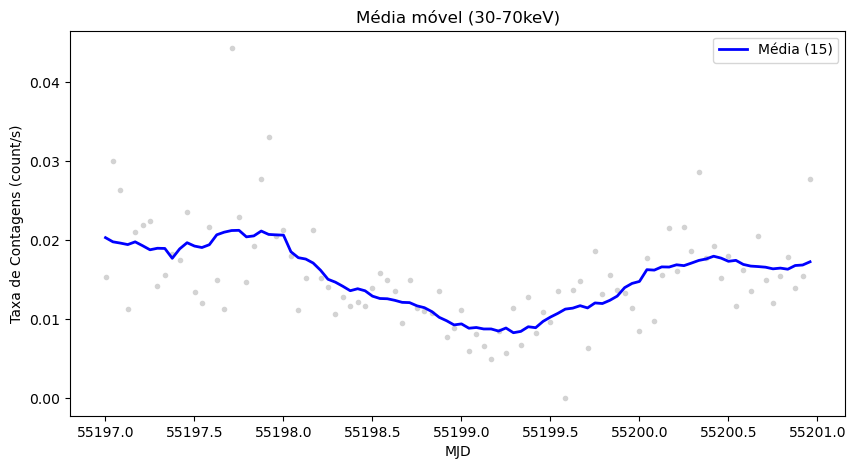

In [28]:
import matplotlib.pyplot as plt
from astropy.table import Table

df = Table.read('nu30201034002A01_sr30-70keV_b1h.lc', hdu=1).to_pandas()
df['MJD'] = 55197.00076601852 + (df['TIME'] / 86400)
df['RATE_SMOOTH'] = df['RATE'].rolling(15, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(df['MJD'], df['RATE'], '.', color='lightgray')
plt.plot(df['MJD'], df['RATE_SMOOTH'], 'b-', linewidth=2, label='Média (15)')

plt.ticklabel_format(useOffset=False, style='plain')

plt.title('Média móvel (30-70keV)')
plt.xlabel('MJD')
plt.ylabel('Taxa de Contagens (count/s)')
plt.legend()
plt.show()

Melhor frequência: 0.3011 dias⁻¹
Período correspondente: 3.3217 dias


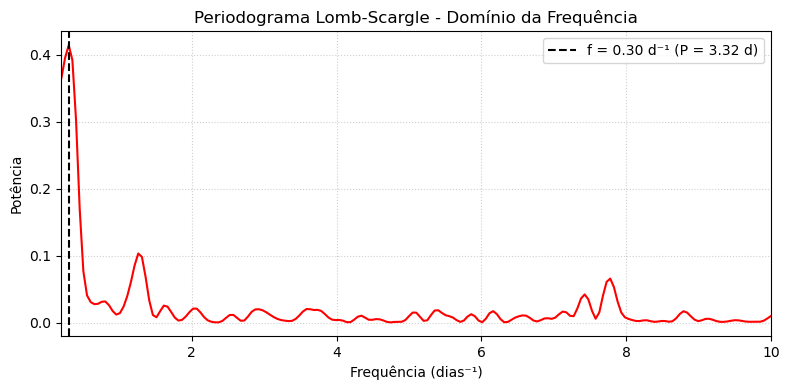

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.timeseries import LombScargle

caminho = 'data/bins 1h/nu30201034002A01_sr30-70keV_b1h.lc'

# 1. Leitura do arquivo FITS
tabela = Table.read(caminho, hdu=1)

# 2. Extração das colunas usando 'tabela'
time = np.array(tabela['TIME'])
rate = np.array(tabela['RATE'])
err = np.array(tabela['ERROR']) if 'ERROR' in tabela.colnames else None

mask = (rate > 0) & ~np.isnan(rate)
t_dias = time[mask] / 86400.0

min_p, max_p = 0.1, 5.0
freq_min, freq_max = 1 / max_p, 1 / min_p  

ls = LombScargle(t_dias, rate[mask], err[mask] if err is not None else None)
freq, power = ls.autopower(
    minimum_frequency=freq_min, maximum_frequency=freq_max
)

idx_pico = np.argmax(power)
best_freq = freq[idx_pico]
best_p = 1 / best_freq

print(f'Melhor frequência: {best_freq:.4f} dias⁻¹')
print(f'Período correspondente: {best_p:.4f} dias')

plt.figure(figsize=(8, 4))
plt.plot(freq, power, 'r-', lw=1.5)
plt.axvline(
    best_freq,
    color='k',
    ls='--',
    label=f'f = {best_freq:.2f} d⁻¹ (P = {best_p:.2f} d)',
)
plt.xlabel('Frequência (dias⁻¹)')
plt.ylabel('Potência')
plt.title('Periodograma Lomb-Scargle - Domínio da Frequência')
plt.xlim(freq_min, freq_max)
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()